# IRSwap PCA Relative Value Butterfly Backtest

**Methodology:** Practitioner-grade PCA RV workflow
- **Stage 1:** Full-curve PCA scan across the forward surface -> Z-score rich/cheap map
- **Stage 2:** Trade-specific PCA on 3 selected tenors -> level+slope-neutral weights
- **Stage 3:** Ornstein-Uhlenbeck mean-reversion analytics (arbitragelab fork)
- **Stage 4:** Carry/roll-down integration + profitability filter

**Curve:** USD SOFR (ERIS EOD LIVE)  
**Structures:** Butterfly trades only  
**Modes:** spot | forward_stanchart | forward_cs

## 1. Setup & Config

In [31]:
%load_ext autoreload
%autoreload 2

import nest_asyncio
nest_asyncio.apply()

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large', 'figure.figsize': (14, 8),
          'axes.labelsize': 'x-large', 'axes.titlesize': 'x-large',
          'xtick.labelsize': 'x-large', 'ytick.labelsize': 'x-large'}
pylab.rcParams.update(params)

import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import datetime, warnings
warnings.filterwarnings('ignore')
import pytz, pandas as pd, numpy as np

from BT.signals.irswap_pca_rv_scanner import (
    IRSwapPCARVConfig, scan_surface, zscore_snapshot,
    identify_candidates, analyze_candidates, build_signal_table,
    build_rate_queries, build_carry_roll_queries,
    reshape_rates_panel, reshape_carry_roll_panel,
)
from BT.signals.irswap_pca_rv_triggers import (
    IRSwapPCARVTrigger, run_irswap_pca_rv_backtest,
)

tz = pytz.timezone('America/New_York')
print('Imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK


In [32]:
# ══════════════════════════════════════════════════════════════
# CONFIGURATION — tweak parameters here for research
# ══════════════════════════════════════════════════════════════
MODE = 'forward_cs'  # 'spot' | 'forward_stanchart' | 'forward_cs'

config = IRSwapPCARVConfig(
    curve='USD-SOFR-1D',
    source='ERIS_EOD_LIVE-RL_BASIC',
    curve_input_mode=MODE,
    pca_window_days=260,
    zscore_lookback_days=130,
    pca_input='levels',
    min_zscore_belly=2,
    min_zscore_wing=0.5,
    max_adf_pvalue=0.25,
    min_half_life_days=3.0,
    max_half_life_days=60,
    auto_scan_fly=True,
    include_carry_roll=True,
    max_concurrent_positions=5,
    trade_belly_bpv=100_000.0,
)

# Date ranges
data_start = datetime.datetime(2022, 1, 1, 17, tzinfo=tz)
data_end = datetime.datetime(2026, 3, 27, 17, tzinfo=tz)
bt_start = datetime.datetime(2024, 6, 1, 17, tzinfo=tz)
bt_end = data_end

print(f'Mode: {config.curve_input_mode}')
print(f'PCA window: {config.pca_window_days}d, Z-score window: {config.zscore_lookback_days}d')
print(f'Min Z belly: {config.min_zscore_belly}, wing: {config.min_zscore_wing}')
print(f'ADF: {config.max_adf_pvalue}, HL: {config.min_half_life_days}-{config.max_half_life_days}d')

Mode: forward_cs
PCA window: 260d, Z-score window: 130d
Min Z belly: 2, wing: 0.5
ADF: 0.25, HL: 3.0-60d


## 2. Data Loading

In [33]:
from TB.TimeseriesBuilder import TimeseriesBuilder
from TB.IRSwapsTB import IRSwapsTB
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

curve_mdp = IRSwapsMDP(source=config.source)
ts_builder = TimeseriesBuilder()
queries = build_rate_queries(config)
router = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=True)}

print(f"Fetching {len(queries)} rate queries...")
rates_df = ts_builder.get_timeseries(
    start=data_start,
    end=data_end,
    queries=queries,
    n_jobs=12,
    routers=router,
	ignore_cache_miss=True,
)
panels = reshape_rates_panel(rates_df, config)
print(f"Loaded panels for {len(panels)} forward starts")

any_panel = next(iter(panels.values()))
print(f"Date range: {any_panel.index[0]} to {any_panel.index[-1]}")
print(f"Panel shape: {any_panel.shape}")

# Carry/roll-down
carry_roll_panels = None
if config.include_carry_roll:
    try:
        cr_queries = build_carry_roll_queries(config)
        print(f"Fetching {len(cr_queries)} carry/roll queries...")
        cr_df = ts_builder.get_timeseries(
            start=data_start,
            end=data_end,
            queries=cr_queries,
            n_jobs=12,
            routers=router,
        )
        carry_roll_panels = reshape_carry_roll_panel(cr_df, config)
        print(f"Loaded carry/roll panels: {len(carry_roll_panels)}")
    except Exception as e:
        print(f"WARNING: Carry/roll failed: {e}")

Fetching 16 rate queries...


Loaded panels for 1 forward starts
Date range: 2022-01-03 to 2026-03-27
Panel shape: (1057, 16)
Fetching 32 carry/roll queries...


Loaded carry/roll panels: 1


## 3. Stage 1: PCA Surface Scan

In [34]:
print('Running Stage 1: Full-curve PCA surface scan...')
result = scan_surface(panels, config)

# Z-score snapshot
snap = zscore_snapshot(result)
if not snap.empty:
    def _color_zscore(val):
        if pd.isna(val): return ''
        if val > 1.5: return 'color: green; font-weight: bold'
        if val > 0: return 'color: green'
        if val < -1.5: return 'color: red; font-weight: bold'
        if val < 0: return 'color: red'
        return ''
    display(snap.style.map(_color_zscore).format('{:.2f}'))

Running Stage 1: Full-curve PCA surface scan...


,Spot
1Y,0.42
1Yx1Y,1.76
2Yx1Y,-1.18
3Yx1Y,-2.30
4Yx1Y,-1.53
5Yx1Y,-0.63
6Yx1Y,-0.44
7Yx1Y,0.05
8Yx1Y,0.67
9Yx1Y,1.24


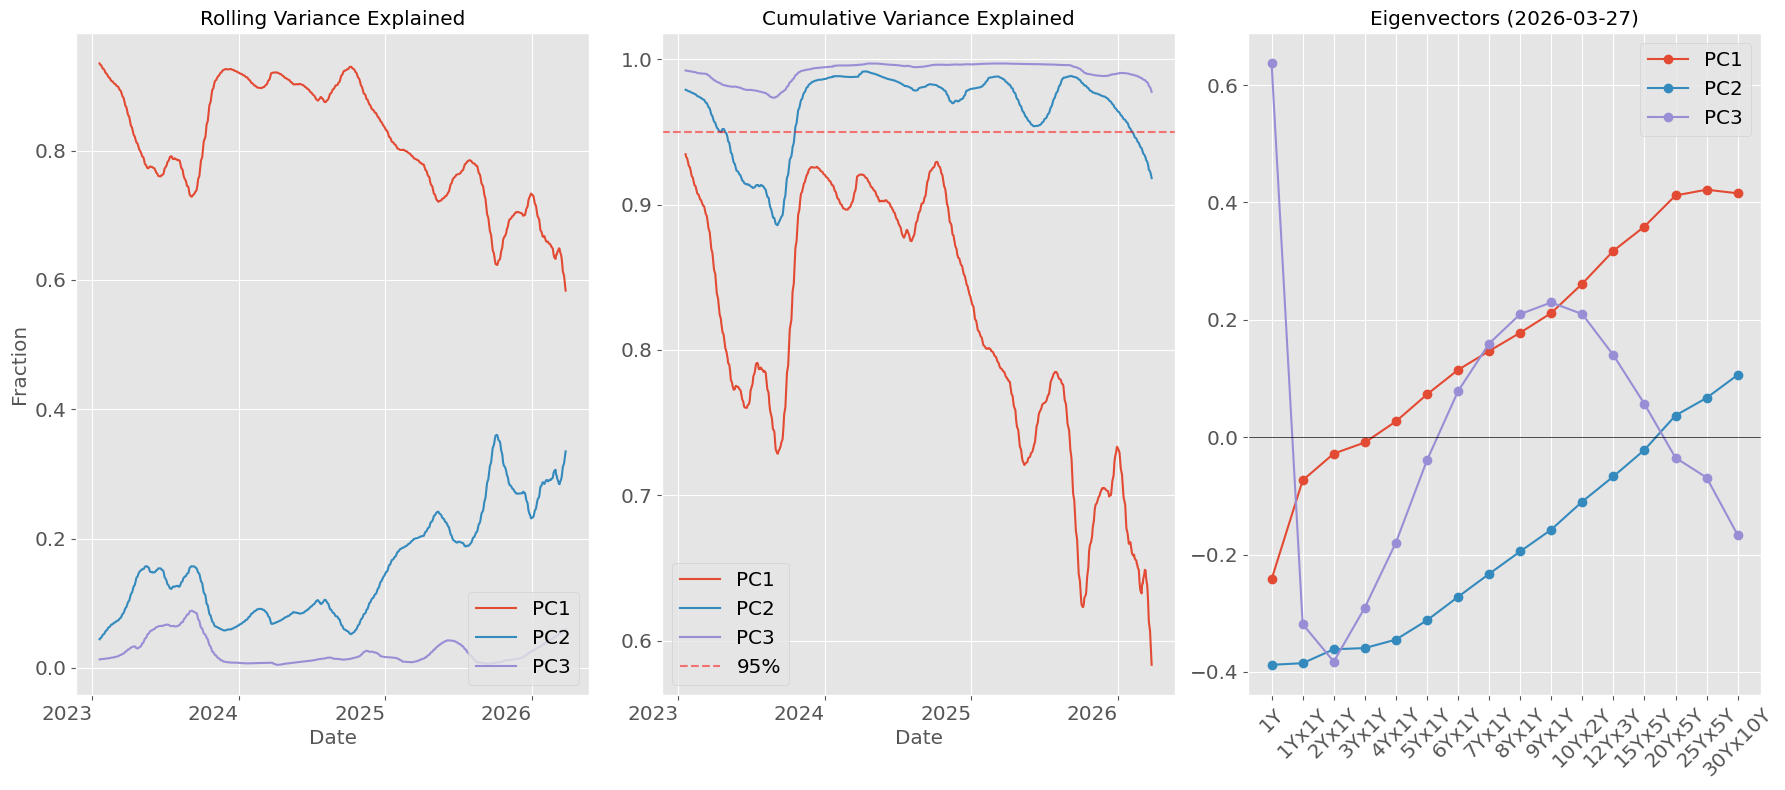

Avg total var explained: 99.2%


In [35]:
# Variance explained + eigenvector shape
fwd_key = None  # Spot curve
if fwd_key in result.variance_explained:
    ve = result.variance_explained[fwd_key].dropna().copy()
    ve.index = pd.to_datetime(ve.index)  # ensure datetime index

    fig, axes = plt.subplots(1, 3, figsize=(18, 8))

    # Rolling variance explained
    ve.plot(ax=axes[0], title="Rolling Variance Explained")
    axes[0].set_ylabel("Fraction")
    axes[0].legend(loc="lower right")

    # Cumulative
    ve.cumsum(axis=1).plot(ax=axes[1], title="Cumulative Variance Explained")
    axes[1].axhline(0.95, color="red", ls="--", alpha=0.5, label="95%")
    axes[1].legend()

    # Better date formatting for time-series axes
    locator = mdates.AutoDateLocator(minticks=3, maxticks=18)
    formatter = mdates.ConciseDateFormatter(locator)
    # formatter = mdates.DateFormatter("%Y-%m")

    for ax in axes[:2]:
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis="x", rotation=0)

    # Latest eigenvector shape
    if result.loadings.get(fwd_key):
        last_date = sorted(result.loadings[fwd_key].keys())[-1]
        eigvecs = result.loadings[fwd_key][last_date]
        tenors = config.get_tenors_for_mode()

        for i in range(min(3, eigvecs.shape[1])):
            axes[2].plot(range(len(tenors)), eigvecs[:, i], "o-", label=f"PC{i+1}")

        axes[2].set_xticks(range(len(tenors)))
        axes[2].set_xticklabels(tenors, rotation=45)
        axes[2].axhline(0, color="black", lw=0.5)

        last_date_fmt = pd.to_datetime(last_date).strftime("%Y-%m-%d")
        axes[2].set_title(f"Eigenvectors ({last_date_fmt})")
        axes[2].legend()

    plt.tight_layout()
    plt.show()
    print(f"Avg total var explained: {ve.sum(axis=1).mean():.1%}")

## 4. Stage 2: Candidates

In [36]:
candidates = identify_candidates(result, panels, config)
print(f'Found {len(candidates)} candidates at latest date')

if candidates:
    cand_df = pd.DataFrame([{
        'Fwd': c.forward_start or 'Spot',
        'Fly': f'{c.tenors[0]}/{c.tenors[1]}/{c.tenors[2]}',
        'Weights': f'{c.weights[0]:.2f} / 1.00 / {c.weights[2]:.2f}',
        'Dir': c.direction,
        'Z(belly)': f'{c.zscore_belly:.2f}',
        'Z(left)': f'{c.zscore_left:.2f}',
        'Z(right)': f'{c.zscore_right:.2f}',
    } for c in candidates])
    display(cand_df)

Found 12 candidates at latest date


,Fwd,Fly,Weights,Dir,Z(belly),Z(left),Z(right)
0,Spot,1Yx1Y/3Yx1Y/8Yx1Y,-0.75 / 1.00 / -0.35,pay_belly,-2.30,1.76,0.67
1,Spot,1Yx1Y/3Yx1Y/9Yx1Y,-0.80 / 1.00 / -0.29,pay_belly,-2.30,1.76,1.24
2,Spot,1Yx1Y/3Yx1Y/10Yx2Y,-0.84 / 1.00 / -0.23,pay_belly,-2.30,1.76,1.60
3,Spot,1Yx1Y/3Yx1Y/12Yx3Y,-0.86 / 1.00 / -0.18,pay_belly,-2.30,1.76,2.23
4,Spot,2Yx1Y/12Yx3Y/20Yx5Y,-0.16 / 1.00 / -0.79,receive_belly,2.23,-1.18,-2.59
5,Spot,2Yx1Y/12Yx3Y/25Yx5Y,-0.21 / 1.00 / -0.76,receive_belly,2.23,-1.18,-1.69
6,Spot,3Yx1Y/12Yx3Y/20Yx5Y,-0.19 / 1.00 / -0.78,receive_belly,2.23,-2.30,-2.59
7,Spot,3Yx1Y/12Yx3Y/25Yx5Y,-0.25 / 1.00 / -0.76,receive_belly,2.23,-2.30,-1.69
8,Spot,4Yx1Y/12Yx3Y/20Yx5Y,-0.23 / 1.00 / -0.76,receive_belly,2.23,-1.53,-2.59
9,Spot,4Yx1Y/12Yx3Y/25Yx5Y,-0.29 / 1.00 / -0.73,receive_belly,2.23,-1.53,-1.69


## 5. Stage 3: OU Analytics

In [37]:
if candidates:
    trades = analyze_candidates(candidates, panels, config, carry_roll_panels)
    print(f'Analyzed {len(trades)} trades')
    passing = [t for t in trades if t.passes_filter]
    print(f'Passing: {len(passing)}')
    
    trade_df = pd.DataFrame([{
        'Fly': '/'.join(t.candidate.tenors),
        'Dir': t.candidate.direction[:3],
        'HL(d)': f'{t.half_life_days:.0f}',
        'ADF-p': f'{t.adf_pvalue:.3f}',
        'Z': f'{t.lifetime_zscore:.2f}',
        'Entry': f'{t.current_level*100:.1f}bp',
        'Target': f'{t.target_level*100:.1f}bp',
        'C+R': f'{t.carry_roll_bps:.2f}bp',
        'P/C': f'{t.profit_cost_ratio:.1f}',
        'Pass': t.passes_filter,
        'Reason': '; '.join(t.filter_reasons) if t.filter_reasons else '',
    } for t in trades])
    display(trade_df)

Analyzed 12 trades
Passing: 0


,Fly,Dir,HL(d),ADF-p,Z,Entry,Target,C+R,P/C,Pass,Reason
0,1Yx1Y/3Yx1Y/8Yx1Y,pay,17467309,0.316,-0.01,-54.9bp,-42.1bp,0.96bp,853.4,False,adf_pvalue=0.316 > 0.25; half_life=17467309.0d...
1,1Yx1Y/3Yx1Y/9Yx1Y,pay,17467309,0.321,-0.01,-50.1bp,-31.8bp,1.02bp,1221.1,False,adf_pvalue=0.321 > 0.25; half_life=17467309.0d...
2,1Yx1Y/3Yx1Y/10Yx2Y,pay,17467309,0.324,-0.01,-41.5bp,-21.5bp,1.19bp,1335.7,False,adf_pvalue=0.324 > 0.25; half_life=17467309.0d...
3,1Yx1Y/3Yx1Y/12Yx3Y,pay,17467309,0.326,-0.01,-26.1bp,-12.1bp,1.33bp,932.9,False,adf_pvalue=0.326 > 0.25; half_life=17467309.0d...
4,2Yx1Y/12Yx3Y/20Yx5Y,rec,17467309,0.091,0.00,87.4bp,85.5bp,0.25bp,129.2,False,half_life=17467309.0d > 60
5,2Yx1Y/12Yx3Y/25Yx5Y,rec,17467309,0.464,0.00,112.1bp,111.9bp,0.17bp,15.9,False,adf_pvalue=0.464 > 0.25; half_life=17467309.0d...
6,3Yx1Y/12Yx3Y/20Yx5Y,rec,17467309,0.061,0.00,77.1bp,73.3bp,0.23bp,250.3,False,half_life=17467309.0d > 60
7,3Yx1Y/12Yx3Y/25Yx5Y,rec,17467309,0.377,-0.00,98.0bp,98.8bp,0.15bp,53.3,False,adf_pvalue=0.377 > 0.25; half_life=17467309.0d...
8,4Yx1Y/12Yx3Y/20Yx5Y,rec,17467309,0.082,0.00,67.2bp,62.1bp,0.12bp,338.1,False,half_life=17467309.0d > 60
9,4Yx1Y/12Yx3Y/25Yx5Y,rec,17467309,0.296,0.00,85.0bp,83.3bp,0.02bp,115.5,False,adf_pvalue=0.296 > 0.25; half_life=17467309.0d...


## 6. Signal Table + Backtest

In [27]:
print(f'Building signal table ({bt_start.date()} to {bt_end.date()})...')
signal_table = build_signal_table(
    panels, config, carry_roll_panels,
    start_date=pd.Timestamp(bt_start), end_date=pd.Timestamp(bt_end),
)
total_sig = sum(len(v) for v in signal_table.values())
passing_sig = sum(sum(1 for t in v if t.passes_filter) for v in signal_table.values())
print(f'Signal table: {len(signal_table)} dates, {total_sig} total, {passing_sig} passing')

Building signal table (2024-06-01 to 2026-03-27)...
Signal table: 330 dates, 11185 total, 0 passing


In [28]:
bt_dates = pd.bdate_range(bt_start, bt_end, tz=tz)
bt_datetimes = [d.to_pydatetime() for d in bt_dates]

print(f'Running backtest: {bt_start.date()} to {bt_end.date()} ({len(bt_datetimes)} steps)')
bt = run_irswap_pca_rv_backtest(signal_table, config, curve_mdp, bt_datetimes)

Running backtest: 2024-06-01 to 2026-03-27 (475 steps)


BACKTESTING...: 100%|██████████| 475/475 [00:00<00:00, 3482.75step/s]


## 7. Results

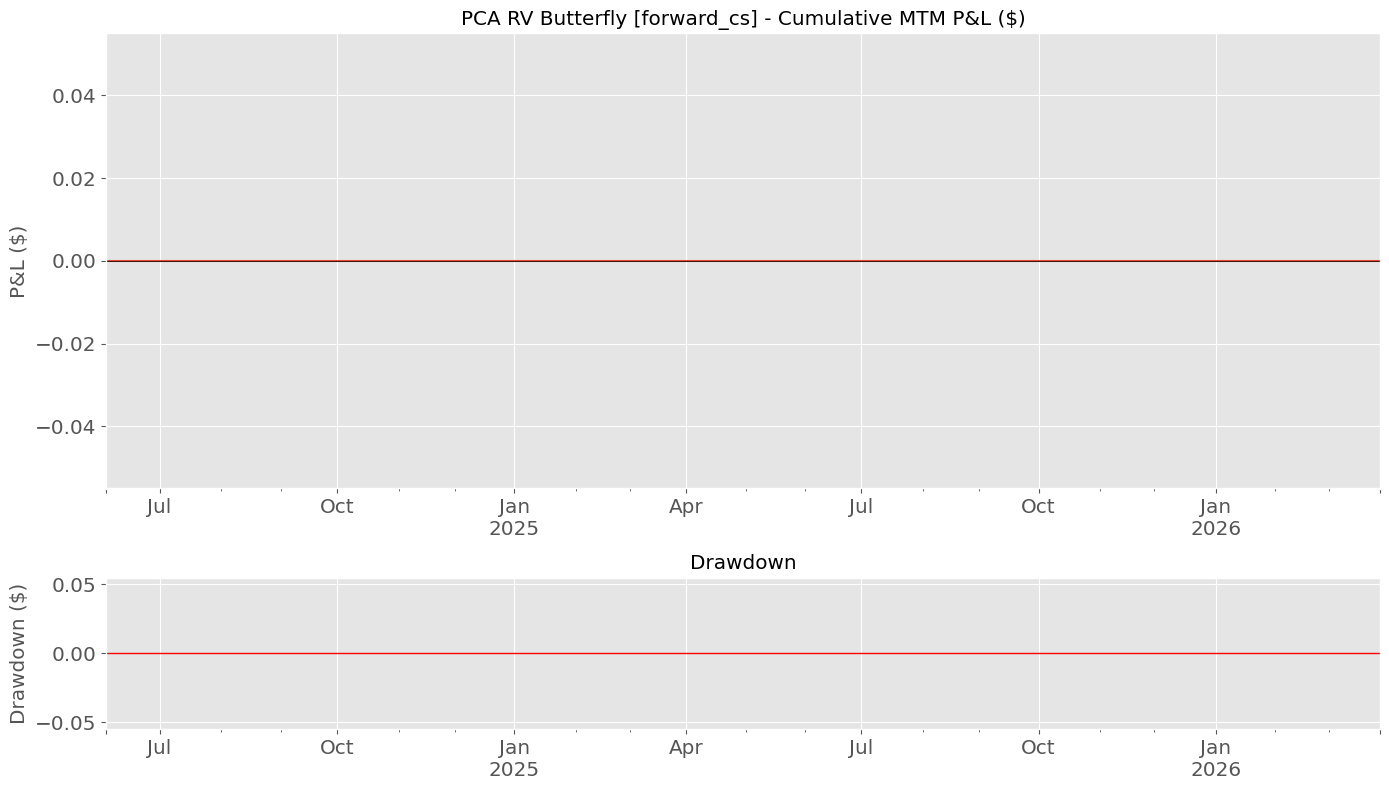

Trades: 0 entries, 0 closed
Final MTM: $0 | Realized: $0
Sharpe: 0.00 | Max DD: $0 | Hit rate: 0.0%


In [29]:
mtm = pd.Series(bt.mtm_history).sort_index()
daily_pnl = mtm.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

mtm.plot(ax=axes[0], title=f'PCA RV Butterfly [{MODE}] - Cumulative MTM P&L ($)', lw=1.5)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_ylabel('P&L ($)')

dd = mtm - mtm.cummax()
dd.plot(ax=axes[1], title='Drawdown', color='red', lw=1)
axes[1].fill_between(dd.index, dd.values, 0, color='red', alpha=0.2)
axes[1].set_ylabel('Drawdown ($)')

plt.tight_layout()
plt.show()

sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0
print(f'Trades: {len(bt.portfolio.trades_log)} entries, {len(bt.portfolio.closed_positions_log)} closed')
print(f'Final MTM: ${mtm.iloc[-1]:,.0f} | Realized: ${bt.realized_pnl:,.0f}')
print(f'Sharpe: {sharpe:.2f} | Max DD: ${dd.min():,.0f} | Hit rate: {(daily_pnl>0).mean():.1%}')

In [30]:
if bt.portfolio.closed_positions_log:
    log_df = pd.DataFrame([{
        'Opened': str(e['opened_at'])[:10],
        'Closed': str(e['closed_at'])[:10],
        'Days': f"{e['holding_period_days']:.0f}",
        'P&L': f"${e['realized_pnl']:,.0f}",
        'Reason': e.get('exit_meta', {}).get('reason', ''),
    } for e in bt.portfolio.closed_positions_log])
    print(f'Closed trade log ({len(log_df)} trades):')
    display(log_df)